# Noisy-OR Shapley Value: Correctness and Performance Study

This notebook studies exact and high-performance algorithms for computing
Shapley values in the **Noisy-OR cooperative game**, defined by

$$
v(S) = 1 - \prod_{j \in S} (1 - w_j),
$$

where each player $i$ has weight $w_i \in [0,1]$.

We compare three implementations provided in `shapley_noisy_OR.py`:

- `brute_force_shapley_all_mpq`  
  Exact exponential-time reference implementation.
- `noisy_or_shapley_mpq`  
  Exact $O(n^2)$ implementation using elementary symmetric sums.
- `noisy_or_shapley_float64`  
  High-performance float64 $O(n^2)$ implementation (NumPy + Numba).

---

## Notebook Structure

**1. Brute-force vs Exact Quadratic Noisy-OR Shapley Benchmark **

- Validates *correctness* of the $O(n^2)$ exact implementation
  against the exponential reference.
- Verifies the efficiency identity:
  $$
  \sum_i \phi_i = v(N)
  $$
- Reports per-$n$ timing comparisons.

**2. Float64 vs Exact Noisy-OR Shapley Benchmark**

- Benchmarks exact $O(n^2)$ vs float64 $O(n^2)$ implementations.
- Measures mean runtime scaling.
- Computes L1 absolute error between float and exact results.

---

This notebook contains no model training or external I/O beyond
timing plots saved to the `images/` directory when enabled.
It is purely an algorithmic correctness and performance study.


## 1. Brute-force vs Exact Quadratic Noisy-OR Shapley Benchmark 

This cell runs a correctness and performance benchmark for the
Noisy-OR Shapley value implementations defined in `shapley_noisy_OR.py`.

The Noisy-OR characteristic function is:

$$
v(S) = 1 - \prod_{j \in S} (1 - w_j),
$$

where each player $i$ has weight $w_i \in [0,1]$.

### What this benchmark does

For each number of players $n \in \{2, \dots, \texttt{max\_n}\}$:

- Draws multiple random weight vectors on a fixed base-10 rational grid  
  (exact `mpq` arithmetic).
- Computes Shapley values using:
  - `brute_force_shapley_all_mpq`  
    (exponential-time exact reference, enabled only for small $n$).
  - `noisy_or_shapley_mpq`  
    (exact $O(n^2)$ implementation using elementary symmetric sums).
- Verifies:
  - **Efficiency (conservation):**
    $$
    \sum_i \phi_i = v(N)
    $$
  - **Exact equality between**
    `brute_force_shapley_all_mpq` and `noisy_or_shapley_mpq`
    (for small $n$).
- Measures mean runtime per sample.

### Output

- Per-$n$ validity report (including mismatch counts when brute-force is enabled).
- Log-scale timing plot comparing:
  - `brute_force_shapley_all_mpq`
  - `noisy_or_shapley_mpq`
- The timing figure is saved to:



n sweep: 100%|█████████████████████████████████████████████████████████████████████████| 99/99 [18:56<00:00, 11.48s/it]



Validity check (Brute + fast give equivalent results): True


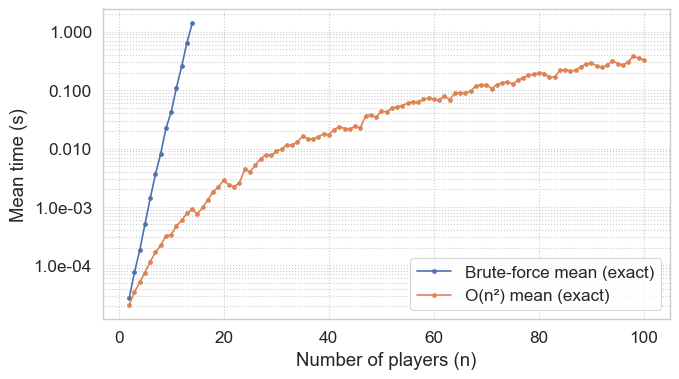

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
from gmpy2 import mpq
from tqdm.auto import tqdm
import time, math

# Add project root (notebook is in ./notebooks; src is a sibling directory)
sys.path.insert(0, str(Path().resolve().parents[0]))

from src.shapley_noisy_OR import (  # noqa: E402
    brute_force_shapley_all_mpq,
    noisy_or_shapley_float64,
    noisy_or_shapley_mpq,
)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# --------------------------------------------------------
# BENCHMARK + CONSISTENCY CHECK (multi-sample per n)
# --------------------------------------------------------
def benchmark_and_check(
    max_n: int = 12,
    samples_per_n: int = 100,
    seed: int = 0,
    max_n_brute: int | None = None,
    n_decimal_places: int = 8,
    verbose: bool = True,
):
    """
    For each n in [2..max_n], draw `samples_per_n` random weight vectors (quantised
    to `n_decimal_places` base-10 decimals) and check:
      - brute vs fast Shapley equality (if n <= max_n_brute)
      - efficiency identity sum(phi) == v_all (always)

    Timing is reported as mean seconds per sample for each n.
    """
    import random

    if max_n_brute is None:
        max_n_brute = max_n

    if n_decimal_places < 0:
        raise AssertionError("n_decimal_places must be >= 0")

    random.seed(seed)

    D = 10 ** n_decimal_places  # exact base-10 quantisation grid

    ns = []
    brute_mean = []
    fast_mean = []
    fast_max = []

    all_equal = True

    for n in tqdm(range(2, max_n + 1), desc="n sweep"):
        brute_times = []
        fast_times = []
        mismatches = 0
    
        for _ in range(samples_per_n):
            weights = [mpq(random.randint(1, D - 1), D) for _ in range(n)]
    
            one = mpq(1)
            prod_comp = one
            for wi in weights:
                prod_comp *= (one - wi)
            v_all = one - prod_comp
    
            # fast
            t0 = time.perf_counter()
            phi_fast = noisy_or_shapley_mpq(weights)
            t1 = time.perf_counter()
            fast_times.append(t1 - t0)
    
            if sum(phi_fast, mpq(0)) != v_all:
                raise AssertionError(
                    f"[fast] efficiency failed: sum={sum(phi_fast, mpq(0))}, v_all={v_all}"
                )
    
            # brute (optional)
            if n <= max_n_brute:
                t0 = time.perf_counter()
                phi_brute = brute_force_shapley_all_mpq(weights)
                t1 = time.perf_counter()
                brute_times.append(t1 - t0)
    
                if sum(phi_brute, mpq(0)) != v_all:
                    raise AssertionError(
                        f"[brute] efficiency failed: sum={sum(phi_brute, mpq(0))}, v_all={v_all}"
                    )
    
                if any(p1 != p2 for p1, p2 in zip(phi_brute, phi_fast)):
                    mismatches += 1
                    all_equal = False



        ns.append(n)
        fast_mean.append(sum(fast_times) / len(fast_times))
        fast_max.append(max(fast_times))

        if n <= max_n_brute:
            brute_mean.append(sum(brute_times) / len(brute_times))
        else:
            brute_mean.append(float("nan"))

        if verbose:
            if n <= max_n_brute:
                status = "✅" if mismatches == 0 else "❌"
                print(
                    f"{status} n={n}: checked {samples_per_n} samples "
                    f"(brute+fast). mismatches={mismatches}. "
                    f"mean_t_brute={brute_mean[-1]:.6f}s, mean_t_fast={fast_mean[-1]:.6f}s"
                )
            else:
                print(
                    f"ℹ️ n={n}: checked {samples_per_n} samples (fast only). "
                    f"mean_t_fast={fast_mean[-1]:.6f}s"
                )

    print("\nValidity check (Brute + fast give equivalent results):", all_equal)


    # --- Plot timing (mean) ---
    plt.figure(figsize=(7, 4))
    
    if any(not math.isnan(x) for x in brute_mean):
        plt.plot(ns, brute_mean, ".-", label="Brute-force mean (exact)")
    
    plt.plot(ns, fast_mean, ".-", label="O(n²) mean (exact)")
    
    plt.yscale("log")
    
    ax = plt.gca()
    
    # Use powers of 10 as major ticks
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
    
    # Format ticks as normal seconds (not log values)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f"{y:.1e}" if y < 0.01 else f"{y:.3f}")
    )
    
    plt.xlabel("Number of players (n)")
    plt.ylabel("Mean time (s)")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.tight_layout()
    plt.savefig("images/benchmark.png", bbox_inches="tight")
    plt.show()


# --------------------------------------------------------
# RUN BENCHMARK
# --------------------------------------------------------
if __name__ == "__main__":
    benchmark_and_check(max_n=100, samples_per_n=100, seed=0, max_n_brute=14, n_decimal_places=8, verbose=False)


## 2. Float64 vs Exact Noisy-OR Shapley Benchmark

This cell benchmarks the two quadratic Noisy-OR Shapley implementations:
the exact rational (`mpq`) method and the float64 (NumPy/Numba) method.

The Noisy-OR characteristic function is:

$$
v(S) = 1 - \prod_{j \in S} (1 - w_j),
$$

where each player $i$ has weight $w_i \in [0,1]$.

### What this benchmark does

For each number of players $n \in \{2, \dots, \texttt{max\_n}\}$:

- Draws multiple random weight vectors on a fixed base-10 grid
  (exact rationals, then converted to float64 for the float run).
- Measures **mean runtime per sample** for:
  - `noisy_or_shapley_float64` (all $n$; includes conservation inside the call)
  - `noisy_or_shapley_mpq` (only for $n \le \texttt{max\_n\_exact}$)
- Computes **absolute error** where the exact reference exists:
  $$
  \text{L1} = \sum_i \lvert \phi_i^{\text{float}} - \phi_i^{\text{exact}} \rvert
  $$

### Output

- Log-scale timing plot.
- Log-scale L1 absolute error plot (only where the exact reference exists).
- If `save_figures=True`, figures are saved to:



n sweep (float vs exact): 100%|██████████████████████████████████████████████████████| 999/999 [32:56<00:00,  1.98s/it]


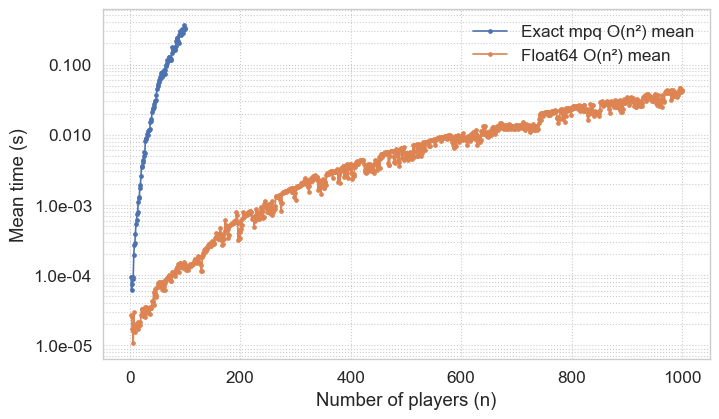

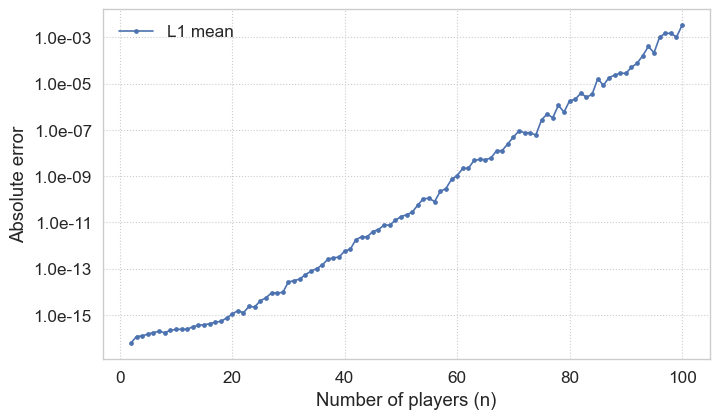

In [9]:
import os
import random 
import numpy as np
from src.shapley_noisy_OR import noisy_or_shapley_float64

def benchmark_float_vs_exact(
    max_n: int = 200,
    samples_per_n: int = 50,
    seed: int = 0,
    n_decimal_places: int = 8,
    max_n_exact: int = 200,          # ONLY cap: mpq reference
    verbose: bool = False,
    save_figures: bool = False,      # default: do NOT save unless asked
    save_prefix: str = "float_vs_exact",
):
    """
    Compare:
      - mpq exact O(n^2) Shapley (reference), only for n <= max_n_exact
      - float64 O(n^2) Shapley (includes conservation), for all n <= max_n

    Produces:
      1) timing vs n (log y, tick labels in seconds)
      2) absolute error vs n (L1 and Linf), only where mpq reference exists

    Returns dict of arrays (no table, no CSV).
    """
    if n_decimal_places < 0:
        raise ValueError("n_decimal_places must be >= 0")

    if save_figures:
        os.makedirs("images", exist_ok=True)

    random.seed(seed)
    D = 10 ** n_decimal_places

    def mpq_list_to_float(phi_mpq):
        return np.array([float(p) for p in phi_mpq], dtype=np.float64)

    def error_metrics(phi_ref: np.ndarray, phi_hat: np.ndarray):
        diff = phi_hat - phi_ref
        l1 = float(np.sum(np.abs(diff)))
        linf = float(np.max(np.abs(diff))) if diff.size else 0.0
        return l1, linf

    # ---- Numba warm-up (compile once; DO NOT TIME) ----
    # Use same argument shape/signature as your real calls:
    _ = noisy_or_shapley_float64(np.array([0.1, 0.2, 0.3], dtype=np.float64), conserve=True)

    ns = []
    t_exact_mean = []
    t_float_mean = []
    l1_mean = []
    linf_mean = []

    for n in tqdm(range(2, max_n + 1), desc="n sweep (float vs exact)"):
        float_times = []
        exact_times = []
        l1s = []
        linfs = []

        for _ in range(samples_per_n):
            # weights on exact base-10 grid, then represented in float
            w_int = np.array([random.randint(1, D - 1) for _ in range(n)], dtype=np.int64)
            w_float = (w_int.astype(np.float64) / float(D)).astype(np.float64)

            # ---- float timing (includes conservation inside noisy_or_shapley_float64) ----
            t0 = time.perf_counter()
            phi_float = noisy_or_shapley_float64(w_float, conserve=True)
            t1 = time.perf_counter()
            float_times.append(t1 - t0)

            # ---- exact timing + error (only if n <= cap) ----
            if n <= max_n_exact:
                weights_mpq = [mpq(int(k), D) for k in w_int.tolist()]

                t0 = time.perf_counter()
                phi_mpq = noisy_or_shapley_mpq(weights_mpq)
                t1 = time.perf_counter()
                exact_times.append(t1 - t0)

                phi_exact_f = mpq_list_to_float(phi_mpq)
                l1, linf = error_metrics(phi_exact_f, phi_float)
                l1s.append(l1)
                linfs.append(linf)

        def _mean(xs):
            return float(np.mean(xs)) if xs else float("nan")

        ns.append(n)
        t_float_mean.append(_mean(float_times))

        if n <= max_n_exact:
            t_exact_mean.append(_mean(exact_times))
            l1_mean.append(_mean(l1s))
            linf_mean.append(_mean(linfs))
        else:
            t_exact_mean.append(float("nan"))
            l1_mean.append(float("nan"))
            linf_mean.append(float("nan"))

        if verbose and n <= max_n_exact:
            print(
                f"n={n}  t_exact={t_exact_mean[-1]:.6f}s  "
                f"t_float={t_float_mean[-1]:.6f}s  "
                f"L1={l1_mean[-1]:.3e}  Linf={linf_mean[-1]:.3e}"
            )

    ns = np.array(ns, dtype=int)
    t_exact_mean = np.array(t_exact_mean, dtype=float)
    t_float_mean = np.array(t_float_mean, dtype=float)
    l1_mean = np.array(l1_mean, dtype=float)
    linf_mean = np.array(linf_mean, dtype=float)

    # ---- Figure 1: timing ----
    plt.figure(figsize=(7.4, 4.4))
    if np.isfinite(t_exact_mean).any():
        plt.plot(ns, t_exact_mean, ".-", label="Exact mpq O(n²) mean")
    plt.plot(ns, t_float_mean, ".-", label="Float64 O(n²) mean")

    plt.yscale("log")
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f"{y:.1e}" if y < 0.01 else f"{y:.3f}")
    )
    plt.xlabel("Number of players (n)")
    plt.ylabel("Mean time (s)")
    plt.grid(True, which="both", ls=":")
    plt.legend(frameon=False)
    plt.tight_layout()
    if save_figures:
        plt.savefig(f"images/{save_prefix}_timing.png", bbox_inches="tight")
    plt.show()

    # ---- Figure 2: absolute error ----
    mask = np.isfinite(l1_mean)
    if mask.any():
        plt.figure(figsize=(7.4, 4.4))
        plt.plot(ns[mask], l1_mean[mask], ".-", label="L1 mean") # |phi_float - phi_exact|
        #plt.plot(ns[mask], linf_mean[mask], ".-", label="L∞ mean |phi_float - phi_exact|")

        plt.yscale("log")
        ax = plt.gca()
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda y, _: f"{y:.1e}" if y < 0.01 else f"{y:.3f}")
        )
        plt.xlabel("Number of players (n)")
        plt.ylabel("Absolute error")
        plt.grid(True, which="both", ls=":")
        plt.legend(frameon=False)
        plt.tight_layout()
        if save_figures:
            plt.savefig(f"images/{save_prefix}_error.png", bbox_inches="tight")
        plt.show()

    return {
        "ns": ns,
        "t_exact_mean_s": t_exact_mean,
        "t_float_mean_s": t_float_mean,
        "L1_mean": l1_mean,
        "Linf_mean": linf_mean,
    }


# Example:
out = benchmark_float_vs_exact(
    max_n=1000,
    samples_per_n=100,
    seed=0,
    max_n_exact=100,
    n_decimal_places=8,
    verbose=False,
    save_figures=True,
)

